# Phân loại nhị phân Pima

In [1]:
# scipy
import scipy
print('scipy: {}'.format(scipy.__version__))
# numpy
import numpy
print('numpy: {}'.format(numpy.__version__))
# matplotlib
import matplotlib
print('matplotlib: {}'.format(matplotlib.__version__))
# pandas
import pandas
print('pandas: {}'.format(pandas.__version__))
# scikit-learn
import sklearn
print('sklearn: {}'.format(sklearn.__version__))

scipy: 1.17.0
numpy: 2.4.2
matplotlib: 3.10.8
pandas: 3.0.0
sklearn: 1.8.0


## 1. Định nghĩa vấn đề (Define Problem)

### **Mô tả bài toán**
* **Mục tiêu**: Dự đoán xem một bệnh nhân có bị khởi phát bệnh tiểu đường trong vòng 5 năm tới hay không.
* **Loại bài toán**: Phân loại nhị phân (Binary Classification).
    * `0` (Negative): Không bị bệnh tiểu đường.
    * `1` (Positive): Bị bệnh tiểu đường (xác định theo tiêu chí WHO: nồng độ glucose huyết tương $\ge$ 200 mg/dl).

---

### **Đối tượng dữ liệu (Study Population)**
* **Nguồn**: Cộng đồng người da đỏ Pima (Pima Indians) gần Phoenix, Arizona, Hoa Kỳ.
* **Đặc điểm**: Đây là quần thể có tỷ lệ mắc bệnh tiểu đường rất cao.
* **Ràng buộc**: Tất cả bệnh nhân trong bộ dữ liệu đều là **nữ giới**, từ **21 tuổi trở lên** và có nguồn gốc Pima Indian.

---

### **Dữ liệu đầu vào (Features)**

| STT | Biến số | Mô tả chi tiết |
| :-- | :--- | :--- |
| 1 | **Pregnancies** | Số lần mang thai của bệnh nhân. |
| 2 | **Glucose** | Nồng độ Glucose huyết tương (đo tại thời điểm 2 giờ trong xét nghiệm GTT). |
| 3 | **Blood Pressure** | Huyết áp tâm trương (mm Hg). |
| 4 | **Skin Thickness** | Độ dày nếp gấp da cơ tam đầu (mm) - dùng để ước lượng lượng mỡ cơ thể. |
| 5 | **Insulin** | Nồng độ Insulin huyết thanh trong 2 giờ (mu U/ml). |
| 6 | **BMI** | Chỉ số khối cơ thể (Cân nặng (kg) / [Chiều cao (m)]^2). |
| 7 | **Diabetes Pedigree** | Chức năng phả hệ: Đánh giá nguy cơ di truyền dựa trên lịch sử bệnh của người thân. |
| 8 | **Age** | Tuổi (tính theo năm). |

---

### **Kết quả (Target Variable)**
* **0**: Không bị bệnh tiểu đường.
* **1**: Bị bệnh tiểu đường.

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1. Khai báo thư viện (Load Libraries)

In [2]:
# Load libraries
import numpy
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

### 2.2. Nạp dữ liệu (Load Dataset)

In [ ]:
# Load dataset 
filename = 'pima-indians-diabetes.data.csv'
names = ['pregs', 'glu', 'bp', 'skin_thick', 'ins', 'bmi', 'pedigree', 'age', 'class']
dataset = read_csv(filename, names=names)

## 3. Tóm tắt dữ liệu (Summarize Data)

### 3.1. Thống kê mô tả (Descriptive Statistics)

**Hiển thị một số thông tin về dữ liệu**

- **Số dòng, số cột**: kích thước bộ dữ liệu (shape).
- **Kiểu dữ liệu của từng cột**: kiểm tra `int`, `float`, `object`... để xác định chuyển đổi cần thiết.
- **Một vài bản ghi (head/tail)**: kiểm tra định dạng và ngoại lệ.
- **Thống kê mô tả (describe)**: như mean, std, min, 25%, 50%, 75%, max.
- **Phân bố lớp mục tiêu**: đếm số mẫu theo từng lớp ở cột class.

In [4]:
# Head, tail
display(dataset.head(5))
display(dataset.tail(5))
dataset.info()

,pregs,glu,bp,skin_thick,ins,bmi,pedigree,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,pregs,glu,bp,skin_thick,ins,bmi,pedigree,age,class
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pregs       768 non-null    int64  
 1   glu         768 non-null    int64  
 2   bp          768 non-null    int64  
 3   skin_thick  768 non-null    int64  
 4   ins         768 non-null    int64  
 5   bmi         768 non-null    float64
 6   pedigree    768 non-null    float64
 7   age         768 non-null    int64  
 8   class       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Shape
print(f'Shape: {dataset.shape}')

Shape: (768, 9)


In [ ]:
# Types
print(f'Data Types: \n{dataset.dtypes}')

In [ ]:
# Descriptive statistics
set_option('display.width', 100)
set_option('display.precision', 3)
description = dataset.describe()
print(description)

         pregs      glu       bp  skin_thick      ins      bmi  pedigree      age    class
count  768.000  768.000  768.000     768.000  768.000  768.000   768.000  768.000  768.000
mean     3.845  120.895   69.105      20.536   79.799   31.993     0.472   33.241    0.349
std      3.370   31.973   19.356      15.952  115.244    7.884     0.331   11.760    0.477
min      0.000    0.000    0.000       0.000    0.000    0.000     0.078   21.000    0.000
25%      1.000   99.000   62.000       0.000    0.000   27.300     0.244   24.000    0.000
50%      3.000  117.000   72.000      23.000   30.500   32.000     0.372   29.000    0.000
75%      6.000  140.250   80.000      32.000  127.250   36.600     0.626   41.000    1.000
max     17.000  199.000  122.000      99.000  846.000   67.100     2.420   81.000    1.000


In [ ]:
# Class distribution
class_counts = dataset.groupby('class').size()
print(class_counts)

class
0    500
1    268
dtype: int64


**Nhận xét**:

- Bộ dữ liệu chứa 8 đặc trưng dùng để phân lớp: `pregs`, `glu`, `bp`, `skin_thick`, `ins`, `bmi`, `pedigree`, `age`.
- Một số biến có đơn vị đo: `glu` (glucose) — mg/dL; `bp` — mm Hg; `skin_thick` — mm; `ins` — mu U/ml; `bmi` — kg/m^2; `age` — years. `pregs` là số lần mang thai; `pedigree` là chỉ số phả hệ (không có đơn vị cụ thể).
- Tổng số dòng dữ liệu: 768 dòng.
- Biến mục tiêu để phân lớp là cột `class` (0 = không bị, 1 = bị).
- Lưu ý: một số giá trị 0 trong các cột `glu`, `bp`, `skin_thick`, `ins`, `bmi` được xem là thiếu và đã được thay thế bằng trung vị trong phần Data Cleaning.
- Kiểm tra phân bố lớp để phát hiện có cân đối chưa trước khi chọn mô hình.

### 3.2. Hiển thị dữ liệu (Data Visualizations)

#### (1). Biểu đồ đơn biến (Univariate Plots)

<Figure size 1400x1000 with 0 Axes>

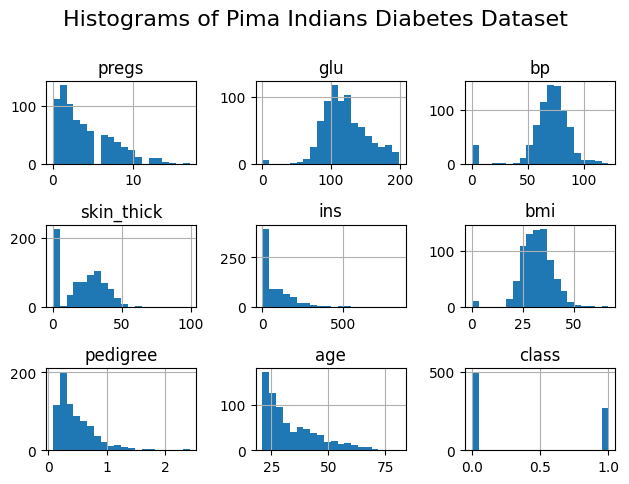

In [9]:
# histograms
pyplot.figure(figsize=(14, 10))
dataset.hist(bins=20, sharex=False, sharey=False)
pyplot.suptitle('Histograms of Pima Indians Diabetes Dataset', fontsize=16, y=1.00)
pyplot.tight_layout()
pyplot.show()

**Nhận xét**:

- Hầu hết các biến có phân bố không chuẩn (skewed), không tuân theo phân bố chuẩn (Gaussian).
- Một số biến (như `ins`, `skin_thick`) có nồng độ cao ở góc trái, cho thấy sự tập trung vào giá trị thấp.
- Biến `age` có hình dạng tương đối đều, trong khi `glu` và `bmi` có hình chuông nhẹ.
- Sự chênh lệch giữa các phân bố gợi ý rằng chuẩn hóa dữ liệu (scaling) sẽ cần thiết trước khi áp dụng các thuật toán.
- Có một số outliers ở phía bên phải của các histogram (giá trị cao bất thường).

<Figure size 1600x1000 with 0 Axes>

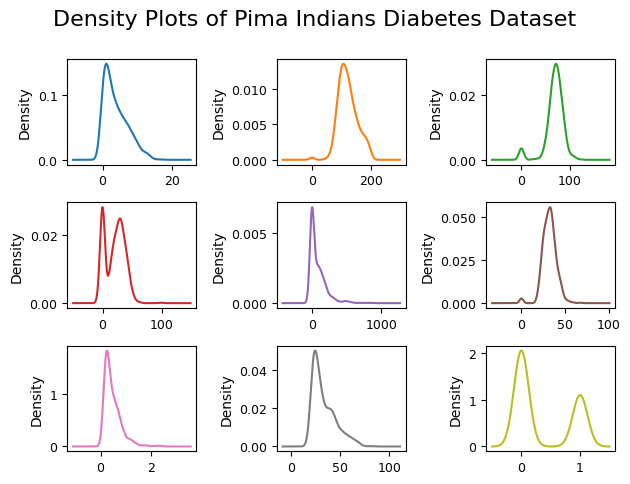

In [10]:
# density
pyplot.figure(figsize=(16, 10))
dataset.plot(kind='density', subplots=True, layout=(3,3), sharex=False, legend=False, fontsize=9)
pyplot.suptitle('Density Plots of Pima Indians Diabetes Dataset', fontsize=16, y=1.00)
pyplot.tight_layout()
pyplot.show()

**Nhận xét**:

- Density plots cung cấp cái nhìn mịn hơn về hình dạng phân bố so với histograms.
- `glu` và `bmi` có hình dạng gần như một đỉnh duy nhất (unimodal), nhưng vẫn có độ lệch (skewness) bên phải.
- `ins` và `skin_thick` có phân bố nhiều đỉnh (multimodal) hoặc có đuôi dài về phía phải (right-skewed).
- `pedigree` có phân bố rất lệch trái mạnh, với phần lớn giá trị tập trung ở khoảng thấp.
- `age` có độ lệch nhẹ nhàng hơn các biến khác, gợi ý rằng tuổi phân bố tương đối đều trên phạm vi khảo sát.
- Sự khác biệt trong các hình dạng phân bố có thể ảnh hưởng đến hiệu suất của các mô hình không giả định phân bố chuẩn (như cây quyết định).

<Figure size 1400x1000 with 0 Axes>

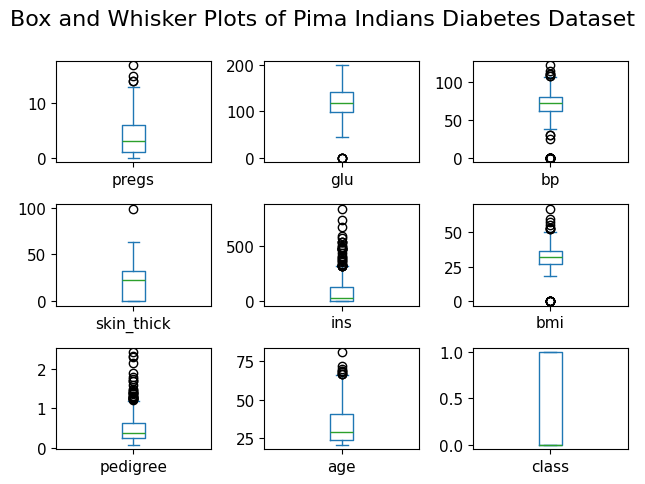

In [11]:
# Box and Whisker Plots
pyplot.figure(figsize=(14, 10))
dataset.plot(kind='box', subplots=True, layout=(3, 3), sharex=False, sharey=False, fontsize=11)
pyplot.suptitle('Box and Whisker Plots of Pima Indians Diabetes Dataset', fontsize=16, y=1.00)
pyplot.tight_layout()
pyplot.show()

**Nhận xét**:

- Box plots giúp phát hiện outliers (giá trị ngoại lệ) ở từng biến thông qua các điểm nằm ngoài whiskers.
- Biến `ins` có rất nhiều outliers (vẽ dưới dạng các chấm nằm phía trên), cho thấy có các giá trị cao bất thường.
- Biến `skin_thick` cũng có một số outliers ở phía trên, tuy nhiên ít hơn `ins`.
- Các biến khác (`pregs`, `glu`, `bp`, `bmi`, `pedigree`, `age`) có outliers theo các mức độ khác nhau.
- Đường trung vị (median line) trong mỗi box không nằm chính giữa hộp, xác nhận phân bố lệch của các biến.
- Chiều dài của hộp (interquartile range — IQR) thay đổi giữa các biến, cho thấy sự biến thiên khác nhau về độ rải.
- Outliers cần được xem xét khi xử lý dữ liệu (có thể loại bỏ hoặc xử lý bằng phương pháp thay thế).

#### (2). Biểu đồ đa biến (Multivariate Plots)

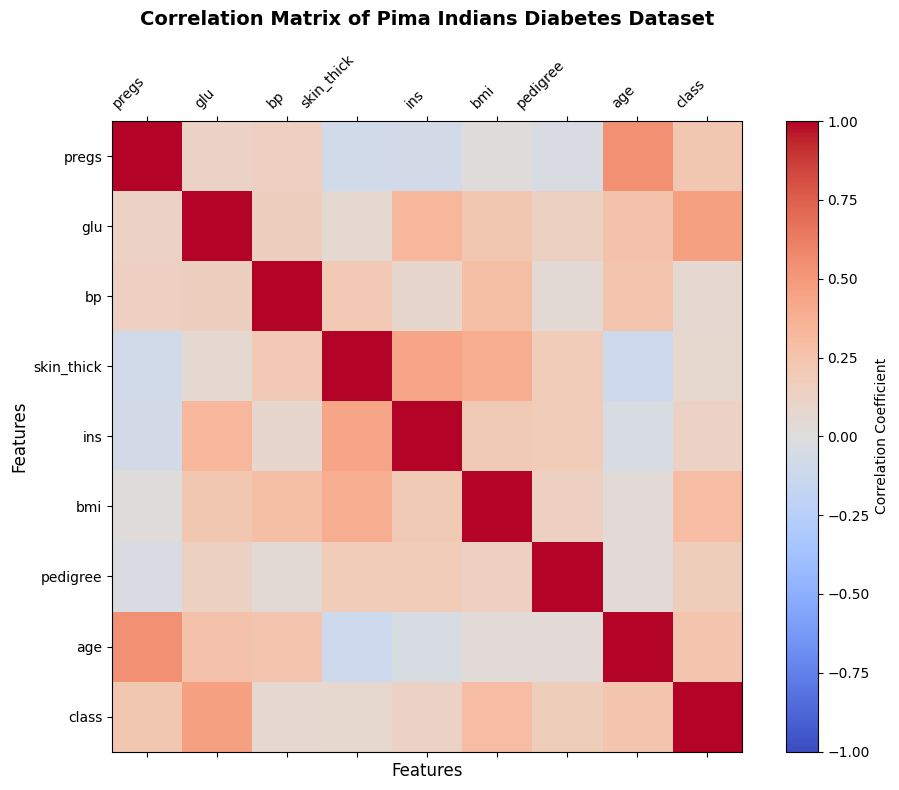

In [12]:
# Correlation Matrix Plot
correlations = dataset.corr()
fig = pyplot.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(cax, label='Correlation Coefficient')
ticks = numpy.arange(0, 9, 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_yticklabels(names)
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Correlation Matrix of Pima Indians Diabetes Dataset', fontsize=14, fontweight='bold', pad=20)
pyplot.tight_layout()
pyplot.show()

**Nhận xét**:

- Ma trận tương quan hiển thị mức độ liên hệ tuyến tính giữa các cặp biến, với giá trị từ -1 (tương quan âm hoàn toàn) đến +1 (tương quan dương hoàn toàn).
- Các ô được tô màu: màu ấm (đỏ/vàng) chỉ tương quan dương mạnh, màu lạnh (xanh/tím) chỉ tương quan âm mạnh, màu trung tính chỉ tương quan yếu.
- Đường chéo chính có giá trị = 1 (mỗi biến tương quan với chính nó) — vùng này được tô màu đỏ rõ nhất.
- Các tương quan mạnh (dương hoặc âm) cần chú ý nếu dùng các mô hình nhạy cảm với multicollinearity (ví dụ: Linear Regression, Logistic Regression).
- Ví dụ: nếu `glu` và `bmi` có tương quan dương mạnh, chúng có thể cung cấp thông tin tương tự cho mô hình.
- Hiểm biến `class` có tương quan chính mạnh với các biến nào sẽ là những dham số dự báo tốt.

<Figure size 1000x800 with 0 Axes>

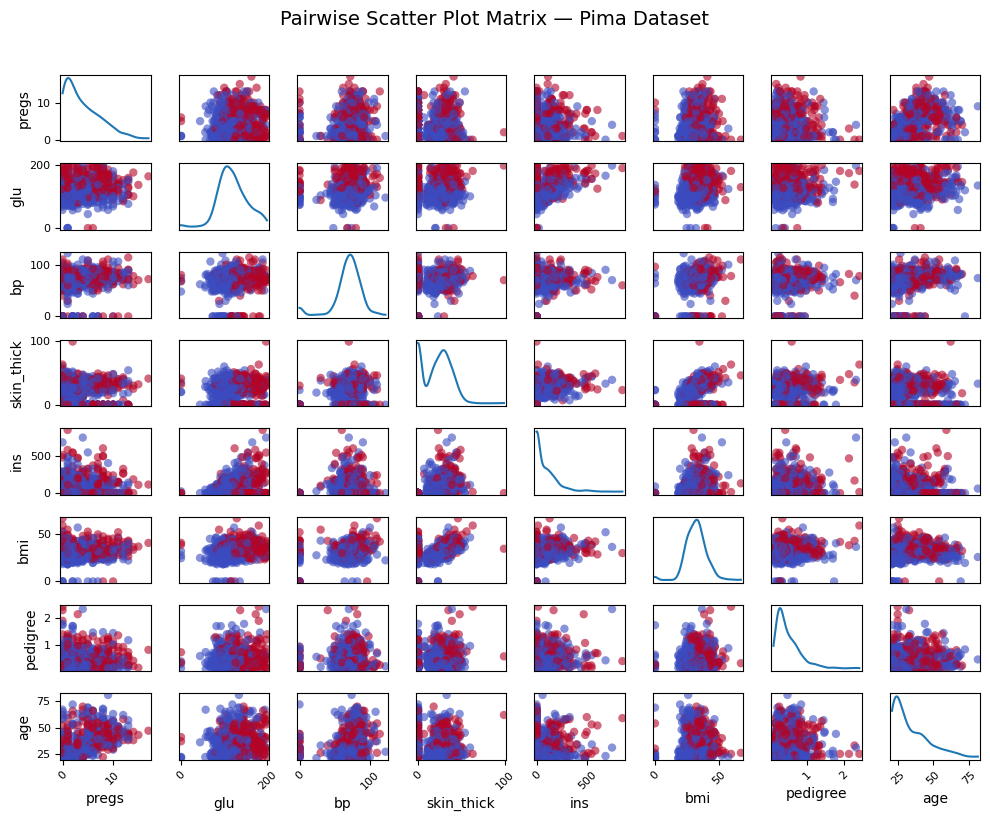

In [ ]:
# Scatter Plot Matrix
scatter_cols = dataset.drop(columns=['class'])
pyplot.figure(figsize=(10, 8))
axes = scatter_matrix(scatter_cols, figsize=(10, 8), diagonal='kde', alpha=0.6, marker='o', c=dataset['class'], cmap='coolwarm', hist_kwds={'bins':20})

for ax in axes.ravel():
    ax.tick_params(axis='x', rotation=45)
pyplot.suptitle('Pairwise Scatter Plot Matrix — Pima Dataset', fontsize=14, y=1.02)
pyplot.tight_layout()
pyplot.show()

**Nhận xét**:

- Scatter plot matrix hiển thị mối quan hệ giữa từng cặp biến (ngoài biến target `class`).
- Đường chéo chính chứa Kernel Density Estimation (KDE) plots thay vì scatter plot, giúp hình dung phân bố một chiều của mỗi biến.
- Các điểm được tô màu theo lớp: màu sắc khác nhau phân biệt lớp 0 (không bị) và lớp 1 (bị bệnh).
- Nếu các điểm của hai lớp phân tách rõ ràng (không trùng lắp), biến đó có khả năng dự báo tốt.
- Nếu các điểm trộn lẫn, biến đó có thể ít hữu ích cho phân loại, hoặc cần kết hợp với các biến khác.
- Các mối quan hệ tuyến tính sẽ hiển thị dưới dạng đường, trong khi các mối quan hệ phi tuyến sẽ có hình dạng cong.
- Các outliers có thể được nhận dạo như những điểm cô lập, đặc biệt ở các vùng màu khác hợp lý.

## 4.Chuẩn bị dữ liệu (Prepare Data)

### 4.1 Data Cleaning

In [ ]:
# Data Cleaning
import numpy as np

# 1. Liệt kê các cột có giá trị 0 "vô lý" (không thể bằng 0 trong thực tế)
columns_to_fix = ['glu', 'bp', 'skin_thick', 'ins', 'bmi']

# 2. Thay thế giá trị 0 bằng NaN (để hàm median() không tính các số 0 này vào trung vị)
dataset[columns_to_fix] = dataset[columns_to_fix].replace(0, np.nan)

# 3. Tính toán và thay thế NaN bằng giá trị Trung vị (Median) của từng cột
dataset.fillna(dataset.median(), inplace=True)

# 4. Kiểm tra lại xem còn giá trị thiếu nào không
print(dataset.isnull().sum())

print(dataset.describe())

pregs         0
glu           0
bp            0
skin_thick    0
ins           0
bmi           0
pedigree      0
age           0
class         0
dtype: int64
         pregs      glu       bp  skin_thick      ins      bmi  pedigree      age    class
count  768.000  768.000  768.000     768.000  768.000  768.000   768.000  768.000  768.000
mean     3.845  121.656   72.387      29.108  140.672   32.455     0.472   33.241    0.349
std      3.370   30.438   12.097       8.791   86.383    6.875     0.331   11.760    0.477
min      0.000   44.000   24.000       7.000   14.000   18.200     0.078   21.000    0.000
25%      1.000   99.750   64.000      25.000  121.500   27.500     0.244   24.000    0.000
50%      3.000  117.000   72.000      29.000  125.000   32.300     0.372   29.000    0.000
75%      6.000  140.250   80.000      32.000  127.250   36.600     0.626   41.000    1.000
max     17.000  199.000  122.000      99.000  846.000   67.100     2.420   81.000    1.000


### 4.2 Lựa chọn đặc trưng (Feature Selection)

In [19]:
# Feature Selection
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# 0. Chuẩn hóa dữ liệu trước khi chọn đặc trưng
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)

# 1. Khởi tạo model dùng để đánh giá tầm quan trọng của đặc trưng
# Chúng ta dùng LogisticRegression vì nó nhanh và ổn định
model_for_selection = LogisticRegression(solver='liblinear')

# 2. Cấu hình RFE: Chọn ra 4 đặc trưng tốt nhất (trong tổng số 8)
# Bạn có thể thay n_features_to_select = 5 hoặc 6 tùy ý
rfe = RFE(estimator=model_for_selection, n_features_to_select=4)
fit = rfe.fit(rescaledX, Y_train)

# 3. Xem kết quả đánh giá
print("Số lượng đặc trưng được chọn: %d" % fit.n_features_)
print("Xếp hạng đặc trưng (1 là tốt nhất): %s" % fit.ranking_)

# Tên các cột tương ứng để bạn dễ theo dõi
feature_names = ['pregs', 'glu', 'bp', 'skin_thick', 'ins', 'bmi', 'pedigree', 'age']
selected_features = [feature_names[i] for i in range(len(fit.support_)) if fit.support_[i]]
print("Các đặc trưng 'vàng' được chọn là: %s" % selected_features)

# 4. Tạo bộ dữ liệu mới chỉ chứa các đặc trưng đã chọn
rescaledX_selected = fit.transform(rescaledX)

Số lượng đặc trưng được chọn: 4
Xếp hạng đặc trưng (1 là tốt nhất): [1 1 2 4 5 1 1 3]
Các đặc trưng 'vàng' được chọn là: ['pregs', 'glu', 'bmi', 'pedigree']


## 5. Evaluate Algorithms

In [ ]:
# Split-out validation dataset
array = dataset.values
X = array[:, 0:8].astype(float)
Y = array[:, 8].astype(int)
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed, stratify=Y)
# Test options and evaluation metric
num_folds = 10
seed = 7
scoring = 'accuracy'
# Spot-Check Algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

c:\CSTTNT25\Tuan06(DA)\DA_Pima\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\CSTTNT25\Tuan06(DA)\DA_Pima\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Pl

LR: 0.755949 (0.053341)
LDA: 0.754336 (0.044839)
KNN: 0.721602 (0.076456)
CART: 0.680804 (0.045615)
NB: 0.744500 (0.054998)
SVM: 0.744553 (0.048513)


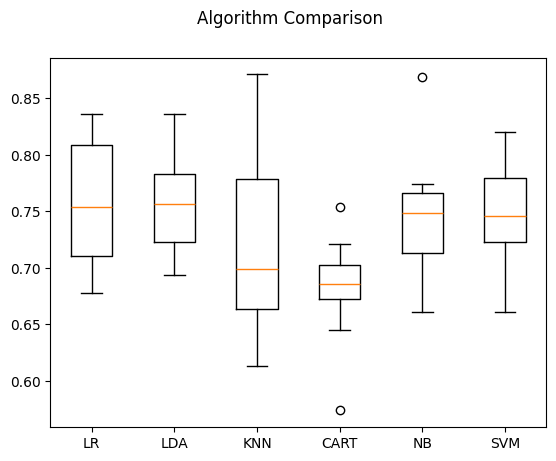

In [21]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

### 5.1. Evaluate Algorithms: Standardize Data

In [22]:
# Standardize the dataset
pipelines = []
pipelines.append(('ScaledLR', Pipeline([('Scaler', StandardScaler()),('LR',
LogisticRegression())])))
pipelines.append(('ScaledLDA', Pipeline([('Scaler', StandardScaler()),('LDA',
LinearDiscriminantAnalysis())])))
pipelines.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()),('KNN',
KNeighborsClassifier())])))
pipelines.append(('ScaledCART', Pipeline([('Scaler', StandardScaler()),('CART',
DecisionTreeClassifier())])))
pipelines.append(('ScaledNB', Pipeline([('Scaler', StandardScaler()),('NB',
GaussianNB())])))
pipelines.append(('ScaledSVM', Pipeline([('Scaler', StandardScaler()),('SVM', SVC())])))
results = []
names = []
for name, model in pipelines:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

ScaledLR: 0.755923 (0.041114)
ScaledLDA: 0.754336 (0.044839)
ScaledKNN: 0.742914 (0.056317)
ScaledCART: 0.676018 (0.048409)
ScaledNB: 0.744500 (0.054998)
ScaledSVM: 0.746060 (0.035612)


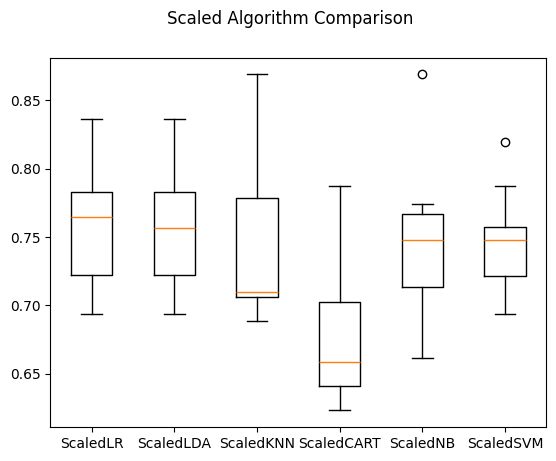

In [23]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

## 6. Tinh chỉnh (Improve Accuracy)

### 6.1 Algorithm Tuning

In [28]:
# Tune scaled LDA
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
shrinkage_values = ['auto', 0.0, 0.3, 0.5, 0.7, 1.0]
param_grid = dict(shrinkage=shrinkage_values)
model = LinearDiscriminantAnalysis(solver='lsqr')
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX_selected, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.770571 using {'shrinkage': 1.0}
0.760762 (0.046170) with: {'shrinkage': 'auto'}
0.755870 (0.039454) with: {'shrinkage': 0.0}
0.759122 (0.041303) with: {'shrinkage': 0.3}
0.765627 (0.041631) with: {'shrinkage': 0.5}
0.768879 (0.039417) with: {'shrinkage': 0.7}
0.770571 (0.040205) with: {'shrinkage': 1.0}


In [29]:
# Tune scaled Logistic Regression
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)

# Thiết lập các giá trị tham số cần thử nghiệm
c_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.3, 1.5, 1.7, 2.0]
penalty_values = ['l1', 'l2']
# 'liblinear' là solver tốt cho cả l1 và l2 trên tập dữ liệu nhỏ/vừa
param_grid = dict(C=c_values, penalty=penalty_values)

model = LogisticRegression(solver='liblinear')
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)

grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX_selected, Y_train)

# In kết quả tốt nhất
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

# In chi tiết tất cả các tổ hợp tham số
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

c:\CSTTNT25\Tuan06(DA)\DA_Pima\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\CSTTNT25\Tuan06(DA)\DA_Pima\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\CSTTNT25\Tuan06(DA)\DA_Pima\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalt

Best: 0.760762 using {'C': 0.1, 'penalty': 'l1'}
0.760762 (0.038801) with: {'C': 0.1, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 0.1, 'penalty': 'l2'}
0.757509 (0.040357) with: {'C': 0.3, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 0.3, 'penalty': 'l2'}
0.759122 (0.038024) with: {'C': 0.5, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 0.5, 'penalty': 'l2'}
0.760762 (0.039510) with: {'C': 0.7, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 0.7, 'penalty': 'l2'}
0.760762 (0.039510) with: {'C': 0.9, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 0.9, 'penalty': 'l2'}
0.760762 (0.039510) with: {'C': 1.0, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 1.0, 'penalty': 'l2'}
0.760762 (0.039510) with: {'C': 1.3, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 1.3, 'penalty': 'l2'}
0.760762 (0.039510) with: {'C': 1.5, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 1.5, 'penalty': 'l2'}
0.760762 (0.039510) with: {'C': 1.7, 'penalty': 'l1'}
0.760762 (0.039510) with: {'C': 1

c:\CSTTNT25\Tuan06(DA)\DA_Pima\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\CSTTNT25\Tuan06(DA)\DA_Pima\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\CSTTNT25\Tuan06(DA)\DA_Pima\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

### 6.2 Ensemble Methods

In [30]:
# ensembles
ensembles = []
ensembles.append(('AB', AdaBoostClassifier()))
ensembles.append(('GBM', GradientBoostingClassifier()))
ensembles.append(('RF', RandomForestClassifier()))
ensembles.append(('ET', ExtraTreesClassifier()))
results = []
names = []
for name, model in ensembles:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

AB: 0.741354 (0.048928)
GBM: 0.754257 (0.049572)
RF: 0.750978 (0.041944)
ET: 0.742702 (0.032184)


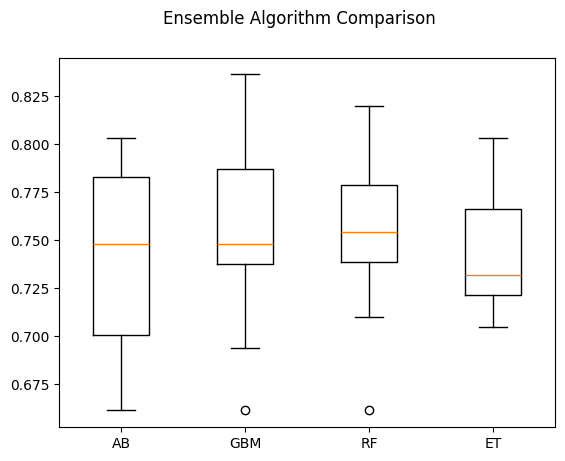

In [32]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Ensemble Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

## 7. Hoàn thiện mô hình (Finalize Model)

In [34]:
# prepare the model
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=1.0)
model.fit(rescaledX, Y_train)
# estimate accuracy on validation dataset
rescaledValidationX = scaler.transform(X_validation)
predictions = model.predict(rescaledValidationX)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.7532467532467533
[[82 18]
 [20 34]]
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       100
           1       0.65      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
# Save Model Using joblib
# This fits a scaler on the training data, trains a LinearDiscriminantAnalysis,
# and saves both the scaler and the model to disk so they can be reused.
from joblib import dump, load
from sklearn.preprocessing import StandardScaler
# Ensure X_train, Y_train, X_validation, Y_validation are defined by running previous cells
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=1.0)
model.fit(rescaledX, Y_train)
# Save both scaler and model in separate files using joblib
scaler_filename = 'finalized_scaler.joblib'
model_filename = 'finalized_model.joblib'
dump(scaler, scaler_filename)
dump(model, model_filename)
print(f'Saved scaler to: {scaler_filename}')
print(f'Saved model to: {model_filename}')
# Example: load back and evaluate on validation set
loaded_scaler = load(scaler_filename)
loaded_model = load(model_filename)
rescaledValidationX = loaded_scaler.transform(X_validation)
predictions = loaded_model.predict(rescaledValidationX)
print('Validation accuracy:', accuracy_score(Y_validation, predictions))

Saved scaler to: finalized_scaler.joblib
Saved model to: finalized_model.joblib
Validation accuracy: 0.7532467532467533
